# EDA — Solar & Wind Resource Across Algeria's Climate Zones

Question this notebook starts to answer: **do the 13 sites actually
separate into meaningfully different renewable profiles, and what drives
the difference?** Before any modeling, we need to see whether "coast vs.
plateau vs. Sahara" is a real signal in the data or just a label we
imposed.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
FIG_DIR = "../reports/figures"
import os
os.makedirs(FIG_DIR, exist_ok=True)

df = pd.read_csv("../data/processed/power_daily_algeria.csv", parse_dates=["date"])
locations = pd.read_csv("../data/locations.csv")

df["month"] = df["date"].dt.month
df["year"] = df["date"].dt.year

# order sites north -> south (the real geographic gradient), derived from
# the data rather than hardcoded
site_order = locations.sort_values("lat", ascending=False)["name"].tolist()
zone_order = (
    locations.sort_values("lat", ascending=False)
    .drop_duplicates("zone")["zone"]
    .tolist()
)
palette = dict(zip(zone_order, sns.color_palette("colorblind", len(zone_order))))

print(df.shape)
df.head()

(94965, 14)


,name,wilaya,zone,date,ALLSKY_SFC_SW_DWN,CLRSKY_SFC_SW_DWN,ALLSKY_SFC_SW_DNI,WS10M,WS50M,T2M,RH2M,PRECTOTCORR,month,year
0,Algiers,Alger,Tell/Coastal,2004-01-01,2.6554,3.0830,5.0023,6.43,7.56,12.69,71.35,0.19,1,2004
1,Algiers,Alger,Tell/Coastal,2004-01-02,1.8787,3.1210,2.4420,9.35,11.14,13.93,69.81,3.99,1,2004
2,Algiers,Alger,Tell/Coastal,2004-01-03,1.4587,2.8865,1.5583,7.62,8.83,12.17,69.53,3.04,1,2004
3,Algiers,Alger,Tell/Coastal,2004-01-04,2.6587,3.2578,5.5932,4.54,5.06,12.65,65.71,0.07,1,2004
4,Algiers,Alger,Tell/Coastal,2004-01-05,3.0521,3.2114,5.9899,3.24,3.54,12.99,67.03,0.02,1,2004


## 1. Clearness index — how predictable is the solar resource?

`ALLSKY_SFC_SW_DWN / CLRSKY_SFC_SW_DWN` measures how much cloud cover
actually knocks down irradiance relative to a cloudless sky. A site
stuck at ~0.55 has structurally cloudy weather; a site at ~0.75+ is
close to its physical ceiling most days — which matters more for
"bankability" than raw average irradiance alone.

In [2]:
df["kt"] = df["ALLSKY_SFC_SW_DWN"] / df["CLRSKY_SFC_SW_DWN"]

kt_stats = (
    df.groupby("name")["kt"]
    .agg(mean_kt="mean", std_kt="std")
    .reindex(site_order)
)
kt_stats["zone"] = locations.set_index("name").loc[kt_stats.index, "zone"]
kt_stats

,mean_kt,std_kt,zone
name,,,
Annaba,0.804659,0.199817,Tell/Coastal
Algiers,0.818600,0.196913,Tell/Coastal
Oran,0.850580,0.169959,Tell/Coastal
Batna,0.828687,0.170152,High Plateau
Tiaret,0.826906,0.191285,High Plateau
Djelfa,0.875664,0.146544,High Plateau
Laghouat,0.902660,0.128249,Saharan Atlas
El Bayadh,0.891370,0.136096,Saharan Atlas
Ghardaia,0.932310,0.111008,Northern Sahara


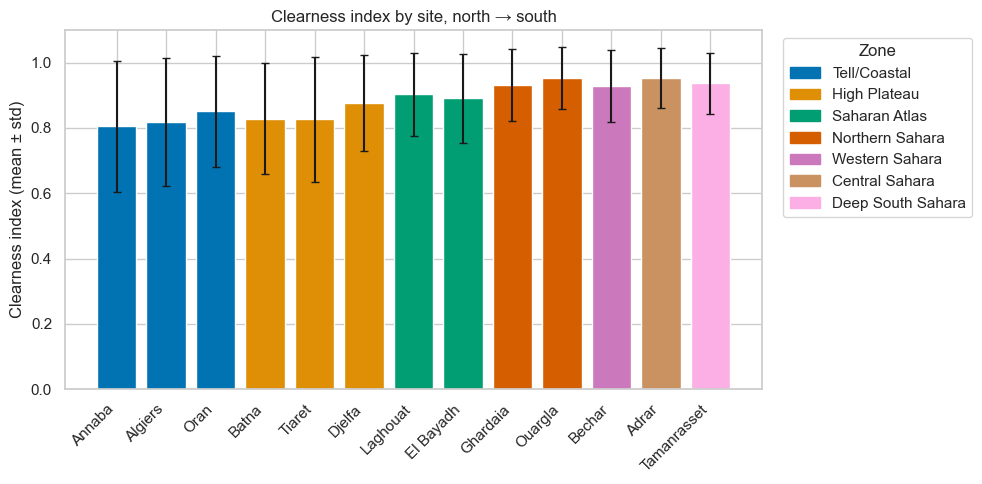

In [3]:
fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(
    kt_stats.index,
    kt_stats["mean_kt"],
    yerr=kt_stats["std_kt"],
    color=[palette[z] for z in kt_stats["zone"]],
    capsize=3,
)
ax.set_ylabel("Clearness index (mean ± std)")
ax.set_title("Clearness index by site, north → south")
plt.xticks(rotation=45, ha="right")
handles = [plt.Rectangle((0, 0), 1, 1, color=palette[z]) for z in zone_order]
ax.legend(handles, zone_order, title="Zone", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/clearness_index_by_site.png", dpi=150)
plt.show()

## 2. Solar & wind resource ranking

Raw annual-mean GHI/DNI tells us "how much energy is physically
available"; wind speed at 50m is a rough turbine hub-height proxy.

In [4]:
annual_means = (
    df.groupby("name")[["ALLSKY_SFC_SW_DWN", "ALLSKY_SFC_SW_DNI", "WS10M", "WS50M", "T2M"]]
    .mean()
    .reindex(site_order)
)
annual_means["zone"] = locations.set_index("name").loc[annual_means.index, "zone"]
annual_means

,ALLSKY_SFC_SW_DWN,ALLSKY_SFC_SW_DNI,WS10M,WS50M,T2M,zone
name,,,,,,
Annaba,4.765907,4.832540,4.356721,5.465376,19.287541,Tell/Coastal
Algiers,4.853028,5.179117,4.957277,5.872943,19.232717,Tell/Coastal
Oran,5.044527,5.447002,4.088864,5.488416,18.775303,Tell/Coastal
Batna,5.012807,4.992734,3.505587,4.956921,13.848428,High Plateau
Tiaret,5.024751,5.154229,3.967644,5.556292,16.802693,High Plateau
Djelfa,5.415605,5.605542,4.646014,6.420157,15.845203,High Plateau
Laghouat,5.628343,5.834539,4.407530,6.228834,18.016979,Saharan Atlas
El Bayadh,5.583426,5.781540,4.648459,6.412141,15.983336,Saharan Atlas
Ghardaia,5.789548,6.001451,4.305238,6.184274,20.793518,Northern Sahara


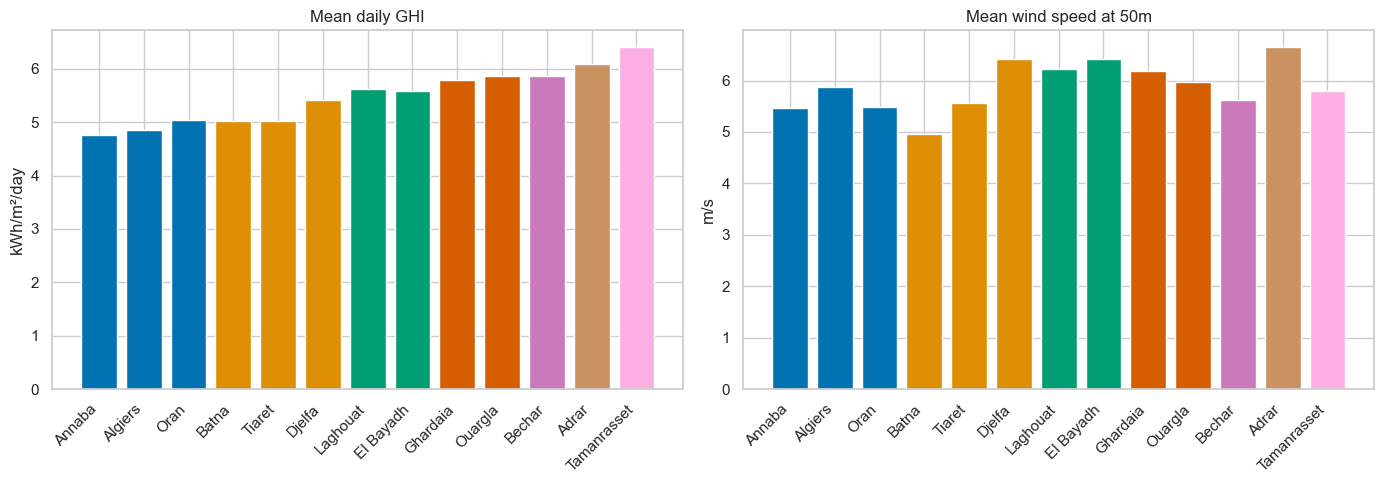

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, col, title, ylabel in zip(
    axes,
    ["ALLSKY_SFC_SW_DWN", "WS50M"],
    ["Mean daily GHI", "Mean wind speed at 50m"],
    ["kWh/m²/day", "m/s"],
):
    ax.bar(
        annual_means.index,
        annual_means[col],
        color=[palette[z] for z in annual_means["zone"]],
    )
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.tick_params(axis="x", rotation=45)
    for label in ax.get_xticklabels():
        label.set_ha("right")

plt.tight_layout()
plt.savefig(f"{FIG_DIR}/solar_wind_ranking.png", dpi=150)
plt.show()

## 3. Seasonal profiles by zone

Averaging sites within each hand-labeled zone, month by month — this is
the first check on whether "zone" is doing real work or is just a label.

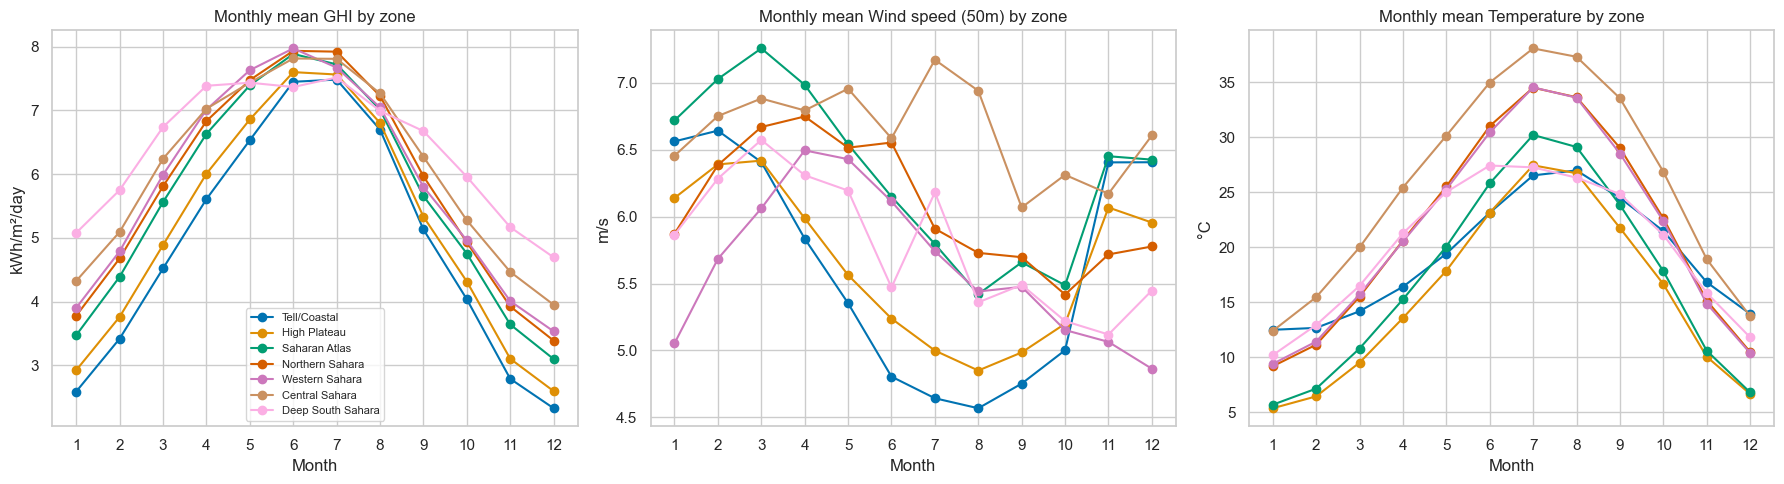

In [6]:
monthly_by_zone = (
    df.merge(locations[["name", "zone"]], on="name", suffixes=("", "_loc"))
    .groupby(["zone", "month"])[["ALLSKY_SFC_SW_DWN", "WS50M", "T2M"]]
    .mean()
    .reset_index()
)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, col, title, ylabel in zip(
    axes,
    ["ALLSKY_SFC_SW_DWN", "WS50M", "T2M"],
    ["GHI", "Wind speed (50m)", "Temperature"],
    ["kWh/m²/day", "m/s", "°C"],
):
    for zone in zone_order:
        sub = monthly_by_zone[monthly_by_zone["zone"] == zone]
        ax.plot(sub["month"], sub[col], marker="o", label=zone, color=palette[zone])
    ax.set_title(f"Monthly mean {title} by zone")
    ax.set_xlabel("Month")
    ax.set_ylabel(ylabel)
    ax.set_xticks(range(1, 13))

axes[0].legend(fontsize=8, loc="lower center")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/seasonal_profiles_by_zone.png", dpi=150)
plt.show()

## 4. Interannual variability — is a good year repeatable?

Average clearness index per site *per year*, then look at the spread
across the 20 years. A site with a high mean but wide year-to-year
spread is a riskier bet for a 25-year asset than a site with a slightly
lower but rock-steady mean.

In [7]:
annual_kt = df.groupby(["name", "year"])["kt"].mean().reset_index()
interannual_spread = (
    annual_kt.groupby("name")["kt"]
    .agg(mean_of_years="mean", std_across_years="std")
    .reindex(site_order)
)
interannual_spread["cv_pct"] = (
    100 * interannual_spread["std_across_years"] / interannual_spread["mean_of_years"]
)
interannual_spread

,mean_of_years,std_across_years,cv_pct
name,,,
Annaba,0.804657,0.017253,2.144124
Algiers,0.818600,0.019263,2.353181
Oran,0.850581,0.016313,1.917852
Batna,0.828686,0.015445,1.863847
Tiaret,0.826907,0.017969,2.173019
Djelfa,0.875665,0.012175,1.390321
Laghouat,0.902660,0.010204,1.130404
El Bayadh,0.891371,0.013086,1.468081
Ghardaia,0.932310,0.007671,0.822755


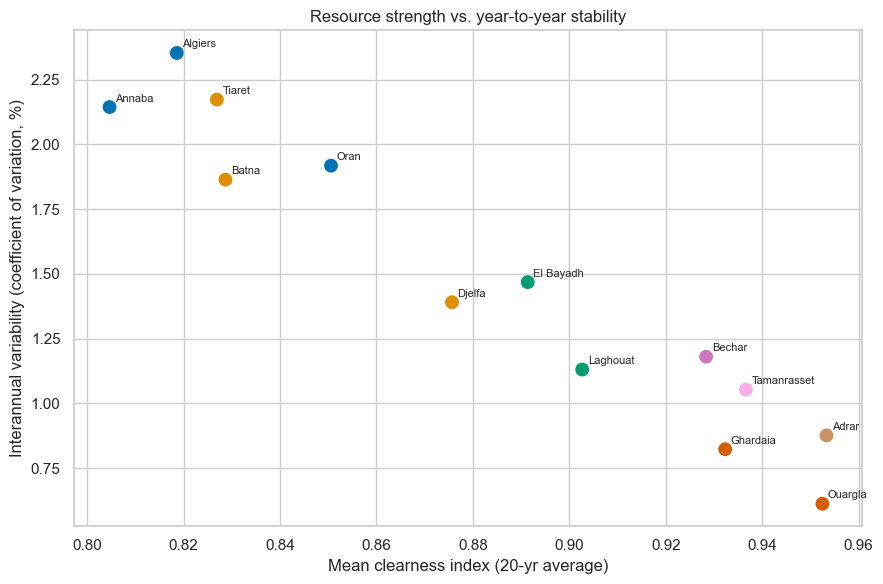

In [8]:
fig, ax = plt.subplots(figsize=(9, 6))
zones_for_sites = locations.set_index("name").loc[interannual_spread.index, "zone"]
ax.scatter(
    interannual_spread["mean_of_years"],
    interannual_spread["cv_pct"],
    c=[palette[z] for z in zones_for_sites],
    s=80,
)
for name, row in interannual_spread.iterrows():
    ax.annotate(name, (row["mean_of_years"], row["cv_pct"]), fontsize=8, xytext=(4, 4), textcoords="offset points")
ax.set_xlabel("Mean clearness index (20-yr average)")
ax.set_ylabel("Interannual variability (coefficient of variation, %)")
ax.set_title("Resource strength vs. year-to-year stability")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/interannual_stability.png", dpi=150)
plt.show()

## 5. Solar/wind complementarity

For each site, does wind tend to be *higher* when solar is *lower*
(a natural hedge for a hybrid plant), or do they move together (no
hedging benefit, possibly compounding risk)? Using monthly climatology
per site to see the seasonal phase relationship, not day-to-day noise.

In [9]:
monthly_by_site = (
    df.groupby(["name", "month"])[["ALLSKY_SFC_SW_DWN", "WS50M"]].mean().reset_index()
)
complementarity = (
    monthly_by_site.groupby("name")
    .apply(lambda g: g["ALLSKY_SFC_SW_DWN"].corr(g["WS50M"]))
    .reindex(site_order)
    .rename("solar_wind_monthly_corr")
)
complementarity_df = complementarity.to_frame()
complementarity_df["zone"] = locations.set_index("name").loc[complementarity_df.index, "zone"]
complementarity_df.sort_values("solar_wind_monthly_corr")

C:\Users\tarek\AppData\Local\Temp\ipykernel_29120\1959113914.py:6: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g["ALLSKY_SFC_SW_DWN"].corr(g["WS50M"]))


,solar_wind_monthly_corr,zone
name,,
Annaba,-0.861481,Tell/Coastal
Tiaret,-0.831534,High Plateau
Oran,-0.771772,Tell/Coastal
Algiers,-0.739837,Tell/Coastal
Batna,-0.502090,High Plateau
Djelfa,-0.452069,High Plateau
Laghouat,-0.335701,Saharan Atlas
El Bayadh,-0.211949,Saharan Atlas
Ghardaia,0.063929,Northern Sahara


Negative correlation = wind climatologically compensates for weaker
solar months at that site (a real hybrid-plant argument). Positive
correlation = the two resources are seasonally aligned, so pairing them
doesn't reduce seasonal variability, it just adds more capacity in the
same good/bad months.

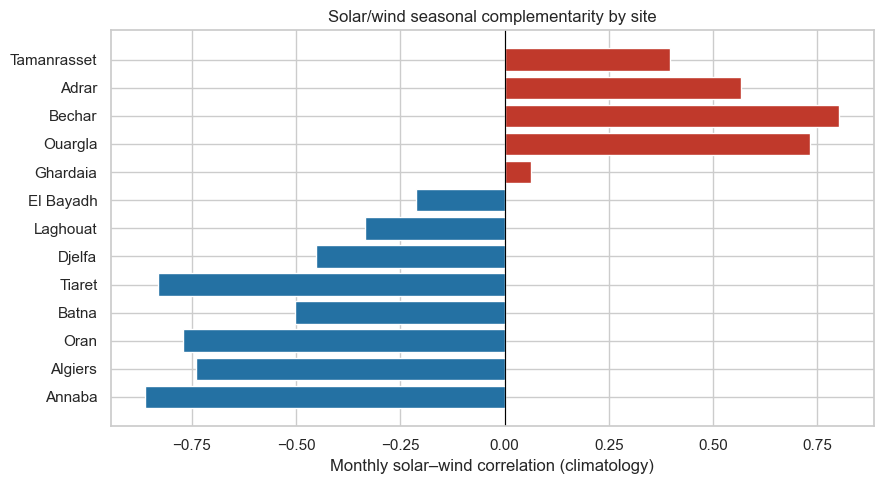

In [10]:
fig, ax = plt.subplots(figsize=(9, 5))
colors = ["#c0392b" if v > 0 else "#2471a3" for v in complementarity_df["solar_wind_monthly_corr"]]
ax.barh(complementarity_df.index, complementarity_df["solar_wind_monthly_corr"], color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Monthly solar–wind correlation (climatology)")
ax.set_title("Solar/wind seasonal complementarity by site")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/solar_wind_complementarity.png", dpi=150)
plt.show()

## 6. Heat exposure — a PV-derating signal

PV panel efficiency drops as cell temperature rises above ~25°C.
Counting days over 35°C air temperature is a rough proxy for which
sites will see real-world yield below their nameplate irradiance would
suggest.

In [11]:
hot_days = (
    df[df["T2M"] > 35]
    .groupby("name")
    .size()
    .reindex(site_order, fill_value=0)
    .rename("days_over_35C_per_20yr")
    .to_frame()
)
hot_days["days_per_year"] = hot_days["days_over_35C_per_20yr"] / 20
hot_days

,days_over_35C_per_20yr,days_per_year
name,,
Annaba,3,0.15
Algiers,0,0.00
Oran,3,0.15
Batna,0,0.00
Tiaret,4,0.20
Djelfa,0,0.00
Laghouat,24,1.20
El Bayadh,0,0.00
Ghardaia,317,15.85


## Summary table for the next stage (clustering)

One row per site with the features that will feed the clustering step:
resource strength, predictability, interannual stability, solar/wind
complementarity, and heat exposure.

In [12]:
summary = (
    annual_means[["ALLSKY_SFC_SW_DWN", "ALLSKY_SFC_SW_DNI", "WS10M", "WS50M", "T2M"]]
    .join(kt_stats[["mean_kt", "std_kt"]])
    .join(interannual_spread[["cv_pct"]].rename(columns={"cv_pct": "interannual_cv_pct"}))
    .join(complementarity_df[["solar_wind_monthly_corr"]])
    .join(hot_days[["days_per_year"]].rename(columns={"days_per_year": "hot_days_per_year"}))
)
summary["zone"] = locations.set_index("name").loc[summary.index, "zone"]
summary["lat"] = locations.set_index("name").loc[summary.index, "lat"]
summary["lon"] = locations.set_index("name").loc[summary.index, "lon"]

summary.to_csv("../data/processed/site_summary_features.csv")
summary

,ALLSKY_SFC_SW_DWN,ALLSKY_SFC_SW_DNI,WS10M,WS50M,T2M,mean_kt,std_kt,interannual_cv_pct,solar_wind_monthly_corr,hot_days_per_year,zone,lat,lon
name,,,,,,,,,,,,,
Annaba,4.765907,4.832540,4.356721,5.465376,19.287541,0.804659,0.199817,2.144124,-0.861481,0.15,Tell/Coastal,36.9000,7.7667
Algiers,4.853028,5.179117,4.957277,5.872943,19.232717,0.818600,0.196913,2.353181,-0.739837,0.00,Tell/Coastal,36.7538,3.0588
Oran,5.044527,5.447002,4.088864,5.488416,18.775303,0.850580,0.169959,1.917852,-0.771772,0.15,Tell/Coastal,35.6969,-0.6331
Batna,5.012807,4.992734,3.505587,4.956921,13.848428,0.828687,0.170152,1.863847,-0.502090,0.00,High Plateau,35.5559,6.1742
Tiaret,5.024751,5.154229,3.967644,5.556292,16.802693,0.826906,0.191285,2.173019,-0.831534,0.20,High Plateau,35.3711,1.3170
Djelfa,5.415605,5.605542,4.646014,6.420157,15.845203,0.875664,0.146544,1.390321,-0.452069,0.00,High Plateau,34.6667,3.2500
Laghouat,5.628343,5.834539,4.407530,6.228834,18.016979,0.902660,0.128249,1.130404,-0.335701,1.20,Saharan Atlas,33.8000,2.8646
El Bayadh,5.583426,5.781540,4.648459,6.412141,15.983336,0.891370,0.136096,1.468081,-0.211949,0.00,Saharan Atlas,33.6803,1.0197
Ghardaia,5.789548,6.001451,4.305238,6.184274,20.793518,0.932310,0.111008,0.822755,0.063929,15.85,Northern Sahara,32.4909,3.6738


## Key findings so far

1. **The zone labels are real, not decorative.** Clearness index rises
   almost monotonically from ~0.80–0.85 on the coast to ~0.93–0.95 deep
   in the Sahara, and interannual variability drops from ~2%+ CV on the
   coast/plateau to under 1% in the desert — the Sahara isn't just
   sunnier, it's also structurally more *predictable* year over year,
   which matters as much as raw resource strength for a 25-year asset.

2. **Solar/wind complementarity flips sign north to south.** Coastal and
   plateau sites show strong *negative* solar–wind correlation
   (Annaba −0.86, Tiaret −0.83, Algiers −0.74): wind climatologically
   compensates for weaker solar months, a real hybrid-plant hedging
   argument. Deep-Sahara sites show the opposite — *positive*
   correlation (Béchar +0.80, Ouargla +0.73, Adrar +0.57): wind and
   solar peak in the same months there, so a hybrid plant adds capacity
   without reducing seasonal variability. This is a genuinely
   non-obvious result and directly informs where a hybrid vs.
   single-resource plant makes sense.

3. **Raw solar ranking is not the same as usable solar ranking.** Adrar
   has the 2nd-highest GHI of all 13 sites but also 87 days/year above
   35°C — enough heat exposure to meaningfully derate real-world PV
   yield (panel efficiency drops with cell temperature). Tamanrasset,
   the single highest-GHI site, sees *zero* days over 35°C in this
   dataset, despite being further south — a coastal-vs-continental /
   altitude effect worth digging into rather than assuming "further
   south = hotter."

These three points are exactly what the clustering stage (next
notebook) needs to test formally: do sites group along resource
strength, or does variability/complementarity/heat produce a different
— and more decision-relevant — typology?